## Purpose
This notebook will identify last 3 months best perfomer

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, current_date, date_sub
import configparser
import os
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from grid_chart_util import create_stock_price_grid
from spark_init import initialize_spark
from config_loader import load_config

In [2]:
tablename = "stocksinfp"
earning_table = "stocks_earnings"
# Load configuration details
try:
    url, driver, username, password = load_config()
    print(f"URL: {url}, Driver: {driver}, Username: {username}, Table: {tablename}")
except Exception as e:
    print(f"Error loading config: {e}")
spark = initialize_spark("25BestVolatile")

URL: jdbc:mysql://localhost/stocksdb, Driver: com.mysql.cj.jdbc.Driver, Username: quizadmin, Table: stocksinfp


Using Spark's default log4j profile: org/apache/spark/log4j-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/19 19:48:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/06/19 19:48:23 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [3]:
stock_df = spark.read.format("jdbc").options(url=url, driver=driver, user=username, password=password, dbtable=tablename).load()
#spark.sparkContext.stop()

In [4]:
# Filter for records in the last 1 year
one_year_ago = date_sub(current_date(), 90)
filtered_df = stock_df.filter(col("Date") >= one_year_ago)
#filtered_df = filtered_df.filter((col("Symbol").isin(['LLY']))) #| (col("Symbol") == 'PANW')
#filtered_df = filtered_df.filter(col("Date").isin(["2024-09-03","2024-08-02","2024-08-05","2024-08-30",
#                                                "2024-07-01","2024-07-02","2024-07-31",
#                                               "2024-06-28","2024-06-05","2024-06-03",
#                                               "2024-05-31","2024-05-30","2024-05-01"]))
# Show the result
filtered_df.show(2, truncate=False)

+----------+-----------------+------------------+-----------------+------------------+------------------+----------+------+------------------+
|Date      |Open             |High              |Low              |Close             |Adj Close         |Volume    |symbol|price_change      |
+----------+-----------------+------------------+-----------------+------------------+------------------+----------+------+------------------+
|2025-03-21|211.2829271905112|218.5533916912833 |211.0032951126973|217.98414611816406|217.98414611816406|94127800.0|AAPL  |4.1645355224609375|
|2025-03-21|209.7912112283105|210.93068989678844|206.8285999522136|208.0869598388672 |208.0869598388672 |16657700.0|ABBV  |-1.932159423828125|
+----------+-----------------+------------------+-----------------+------------------+------------------+----------+------+------------------+
only showing top 2 rows



In [5]:
# Convert Spark DataFrame to Pandas DataFrame
pandas_df = filtered_df.select("date","symbol","close").toPandas()

# Convert all column headers to lowercase
pandas_df.columns = pandas_df.columns.str.lower()
pandas_df['date'] = pd.to_datetime(pandas_df['date'])


# Display the Pandas DataFrame
print(pandas_df.head(2))

        date symbol               close
0 2025-03-21   AAPL  217.98414611816406
1 2025-03-21   ABBV   208.0869598388672


In [6]:
print(pandas_df['close'].dtype)
pandas_df['close'] = pd.to_numeric(pandas_df['close'], errors='coerce')

# Display the Pandas DataFrame
print(pandas_df.head(2))

object
        date symbol       close
0 2025-03-21   AAPL  217.984146
1 2025-03-21   ABBV  208.086960


In [7]:
# Dropping rows where 'close' is NaN (optional, based on your use case)
df = pandas_df.dropna(subset=['close'])

print(df.head(2))

        date symbol       close
0 2025-03-21   AAPL  217.984146
1 2025-03-21   ABBV  208.086960


In [8]:

# Sort the DataFrame by 'symbol' and 'date'
df = df.sort_values(['symbol', 'date'])

# Create a 'year_month' column
df['year_month'] = df['date'].dt.to_period('M')

# Get the current date
current_date = datetime.datetime.now()
current_year_month = pd.Period(current_date, freq='M')

# Function to get first and last rows, handling current month specially
def get_first_last(group):
    group = group.sort_values('date')
    if len(group) == 1 and group['year_month'].iloc[0] == current_year_month:
        return pd.Series({
            'month_start_price': float('nan'),  # We'll fill this later
            'month_end_price': group['close'].iloc[0],
            'month_start_date': group['date'].iloc[0],
            'month_end_date': group['date'].iloc[0],
            'is_current_month': True
        })
    else:
        return pd.Series({
            'month_start_price': group['close'].iloc[0],
            'month_end_price': group['close'].iloc[-1],
            'month_start_date': group['date'].iloc[0],
            'month_end_date': group['date'].iloc[-1],
            'is_current_month': group['year_month'].iloc[0] == current_year_month
        })

# Calculate the monthly price data
monthly_data = df.groupby(['symbol', 'year_month']).apply(get_first_last).reset_index()
#monthly_data = df.groupby(['symbol', 'year_month']).apply(get_first_last).reset_index(drop=True)


# Sort the monthly data by symbol and year_month
monthly_data = monthly_data.sort_values(['symbol', 'year_month'])

# Fill in the start price for the current month if it's NaN
for symbol in monthly_data['symbol'].unique():
    symbol_data = monthly_data[monthly_data['symbol'] == symbol]
    current_month_row = symbol_data[symbol_data['is_current_month'] & symbol_data['month_start_price'].isna()]
    
    if not current_month_row.empty:
        prev_month_row = symbol_data[symbol_data['year_month'] < current_year_month].iloc[-1] if len(symbol_data) > 1 else None
        if prev_month_row is not None:
            monthly_data.loc[current_month_row.index, 'month_start_price'] = prev_month_row['month_end_price']

# Calculate the price increase
monthly_data['monthly_increase'] = monthly_data['month_end_price'] - monthly_data['month_start_price']

# Calculate the percentage increase
monthly_data['monthly_increase_percent'] = (monthly_data['monthly_increase'] / monthly_data['month_start_price']) * 100

# Merge the calculated monthly increase back into the original DataFrame
df = df.merge(
    monthly_data[['symbol', 'year_month', 'monthly_increase', 'monthly_increase_percent', 'month_start_price', 'month_end_price', 'is_current_month']],
    on=['symbol', 'year_month'],
    how='left'
)

# Clean up
df = df.drop('year_month', axis=1)

# Set 'date' as index if desired
df = df.set_index('date')

# Display the results
#print(df[['symbol', 'close', 'monthly_increase', 'monthly_increase_percent', 'month_start_price', 'month_end_price', 'is_current_month']].head(10))

# Optional: If you want to see the monthly increase for each month
print("\nMonthly increase for each month:")
print(monthly_data[['symbol', 'year_month', 'month_start_date', 'month_end_date', 'month_start_price', 'month_end_price', 'monthly_increase', 'monthly_increase_percent', 'is_current_month']].head(10))


Monthly increase for each month:
  symbol year_month month_start_date month_end_date  month_start_price  \
0   AAPL    2025-03       2025-03-21     2025-03-31         217.984146   
1   AAPL    2025-04       2025-04-01     2025-04-30         222.897705   
2   AAPL    2025-05       2025-05-01     2025-05-30         213.040634   
3   AAPL    2025-06       2025-06-02     2025-06-18         201.699997   
4   ABBV    2025-03       2025-03-21     2025-03-31         208.086960   
5   ABBV    2025-04       2025-04-01     2025-04-30         204.381210   
6   ABBV    2025-05       2025-05-01     2025-05-30         193.339996   
7   ABBV    2025-06       2025-06-02     2025-06-18         186.990005   
8    ACB    2025-03       2025-03-21     2025-03-31           4.460000   
9    ACB    2025-04       2025-04-01     2025-04-30           4.370000   

   month_end_price  monthly_increase  monthly_increase_percent  \
0       221.839096          3.854950                  1.768454   
1       212.221710 

/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_9744/2760424660.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_data = df.groupby(['symbol', 'year_month']).apply(get_first_last).reset_index()


In [9]:
# Step 6: Filter the dataframe for the top 25 symbols based on 3-month increases
# For demonstration purposes, we'll consider 'monthly_increase' over the last 3 months.

# Get the current date and calculate the date 3 months ago
current_date = datetime.datetime.now()
three_months_ago = current_date - pd.DateOffset(months=3)

# Filter the monthly data for the last 3 months
last_3_months_data = monthly_data[monthly_data['month_end_date'] > three_months_ago]

# Calculate the cumulative 3-month increase for each symbol
cumulative_increase = last_3_months_data.groupby('symbol').agg({
    'monthly_increase': 'sum',
    'month_start_price': 'first',
    'month_end_price': 'last'
}).reset_index()

cumulative_increase['cumulative_percent_increase'] = (
    (cumulative_increase['month_end_price'] - cumulative_increase['month_start_price']) / 
    cumulative_increase['month_start_price'] * 100
)

# Sort by cumulative percent increase and get the top 25 symbols
top_25_symbols = cumulative_increase.sort_values('cumulative_percent_increase', ascending=False).head(25)

# Filter the original dataframe for these top 25 symbols
df_top_25 = monthly_data[monthly_data['symbol'].isin(top_25_symbols['symbol'])]

# Display the results
print("Top 25 Symbols Based on 3-Month Increase:")
print(top_25_symbols[['symbol', 'cumulative_percent_increase']])

print("\nSample of filtered dataframe (first 10 rows):")
print(df_top_25[['symbol', 'month_start_date','month_start_price', 'month_end_price', 'monthly_increase', 'monthly_increase_percent']].head(10))

# Optional: Save the filtered dataframe to a CSV file
#df_top_25.to_csv('top_25_symbols_3_month_increase.csv', index=True)
#print("\nFiltered dataframe saved to 'top_25_symbols_3_month_increase.csv'")

Top 25 Symbols Based on 3-Month Increase:
    symbol  cumulative_percent_increase
188   RAPT                   466.412244
65    CRWV                   325.000000
207   SEZL                   263.743480
222   SRNE                   200.000000
81    EBET                   199.999988
187   QUBT                   158.322064
131     ME                   149.720664
24    ARQQ                   114.156809
54     CMP                    94.383136
45    BYSI                    94.374991
23    APPS                    91.477267
140   NEGG                    87.999996
181   QBTS                    87.918668
156   OCGN                    80.165289
235   TMDX                    79.580007
82    EDIT                    79.389314
139   NBIS                    79.095628
225   STRL                    76.869625
107   HOOD                    76.623078
106   HIMS                    75.741006
189   RBLX                    67.838459
91    FIVE                    61.568735
157    ODD                    61.01108

In [10]:
# Convert 'date' to datetime format and create a 'year_month' column for grouping
df = df_top_25
df['month_start_date'] = pd.to_datetime(df['month_start_date'])
df['year_month'] = df['month_start_date'].dt.to_period('M')

# Convert 'year_month' to string for proper ordering in plot
df['year_month_str'] = df['year_month'].astype(str)

# Fill NaN values
df['monthly_increase'] = df['monthly_increase'].fillna(0.0)

# Ensure 'year_month_str' is treated as categorical with a specific order
df['year_month_str'] = pd.Categorical(df['year_month_str'], categories=sorted(df['year_month_str'].unique()), ordered=True)

# Aggregate data
agg_df = df.groupby(['year_month_str', 'symbol'], observed=False).agg(
    total_monthly_increase=('monthly_increase', 'sum'),
    avg_percentage_increase=('monthly_increase_percent', 'mean')
).reset_index()

# Fill NaN values with 0 in 'monthly_increase' and 'percentage_increase'
agg_df['total_monthly_increase'] = agg_df['total_monthly_increase'].fillna(0)
agg_df['avg_percentage_increase'] = agg_df['avg_percentage_increase'].fillna(0)
agg_df = agg_df[agg_df['total_monthly_increase'] > 0]
print(agg_df)

   year_month_str symbol  total_monthly_increase  avg_percentage_increase
15        2025-03   OCGN                0.101000                16.694206
18        2025-03   QUBT                0.610000                 8.254400
26        2025-04   APPS                0.180000                 6.382981
27        2025-04   ARQQ                2.080000                15.499254
28        2025-04   BYSI                0.120000                 7.407408
..            ...    ...                     ...                      ...
95        2025-06   RBLX               12.700005                14.118961
96        2025-06   SEZL               30.510002                27.115182
97        2025-06   SRNE                0.000800                61.538455
98        2025-06   STRL               34.369995                18.127634
99        2025-06   TMDX                0.059998                 0.048409

[63 rows x 4 columns]


/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_9744/1769079552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_start_date'] = pd.to_datetime(df['month_start_date'])
/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_9744/1769079552.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_month'] = df['month_start_date'].dt.to_period('M')
/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_9744/1769079552.py:7: SettingWithCopyWarning: 
A value is trying to be set 

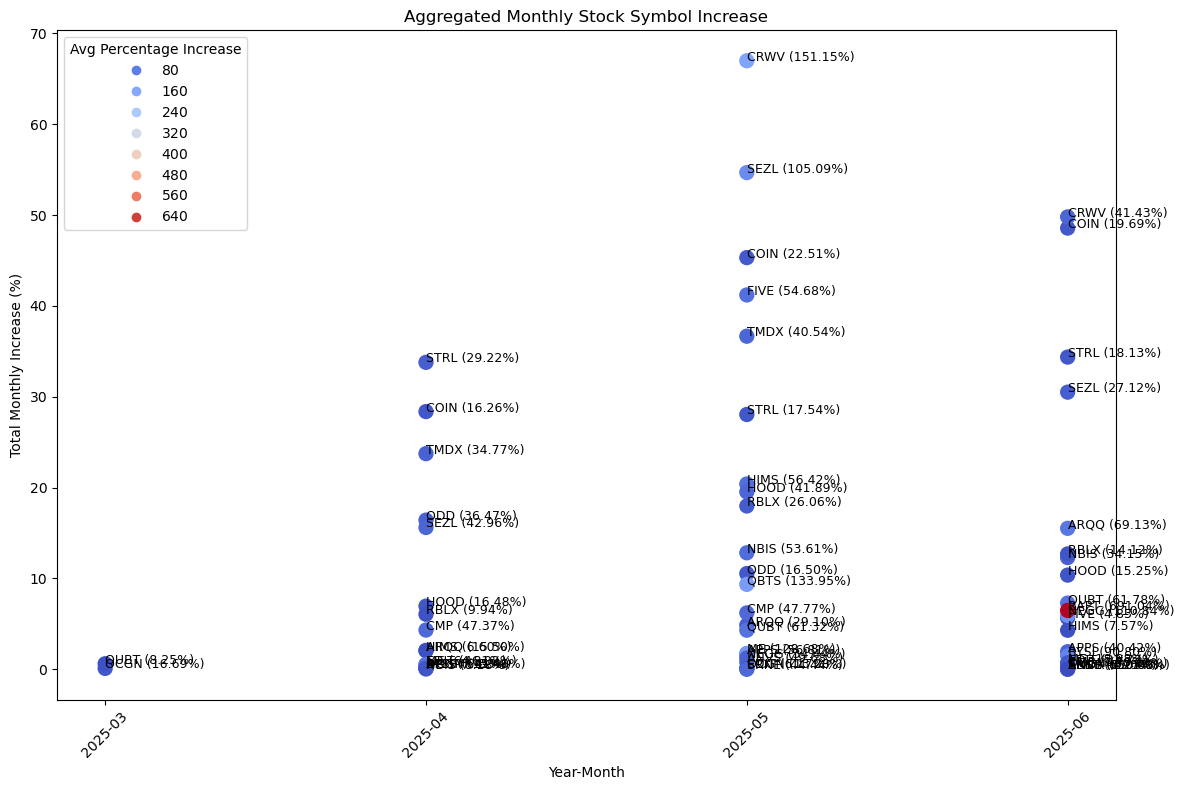

In [11]:
# Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot
scatter = ax.scatter(
    agg_df['year_month_str'],
    agg_df['total_monthly_increase'],
    c=agg_df['avg_percentage_increase'],
    cmap='coolwarm',
    s=100
)

# Add labels
for i, row in agg_df.iterrows():
    ax.text(row['year_month_str'], row['total_monthly_increase'], f"{row['symbol']} ({row['avg_percentage_increase']:.2f}%)", fontsize=9)

# Formatting
ax.set_xticks(agg_df['year_month_str'].cat.categories)
ax.set_xticklabels(agg_df['year_month_str'].cat.categories, rotation=45)
ax.set_title('Aggregated Monthly Stock Symbol Increase')
ax.set_xlabel('Year-Month')
ax.set_ylabel('Total Monthly Increase (%)')
ax.legend(*scatter.legend_elements(), title='Avg Percentage Increase')

plt.tight_layout()
plt.show()

In [12]:
import numpy as np

#print(agg_df)
# Group the data by symbol and month, then calculate the mean percentage increase
grouped = agg_df.groupby(['symbol', 'year_month_str'],observed=False)['avg_percentage_increase'].mean().unstack()

# Fill NaN values with 0
grouped = grouped.fillna(0)

# Calculate the overall percentage increase for each symbol
overall_increase = grouped.sum(axis=1)

#print(grouped)
# Sort the DataFrame by the total percentage increase (sum across all months)
#sorted_df = grouped.sort_values(by=grouped.columns.tolist(), ascending=True)
sorted_df = grouped.loc[overall_increase.sort_values().index]
print(sorted_df)

year_month_str    2025-03    2025-04     2025-05     2025-06
symbol                                                      
RBLX             0.000000   9.936057   26.057976   14.118961
ANVS             0.000000   0.000000   49.681518    2.272725
ODD              0.000000  36.472674   16.497106    0.000000
COIN             0.000000  16.256013   22.513657   19.686287
FIVE             0.000000   0.000000   54.684181    4.825120
STRL             0.000000  29.219987   17.535626   18.127634
HIMS             0.000000   6.602252   56.415934    7.574422
HOOD             0.000000  16.484822   41.891898   15.254479
TMDX             0.000000  34.773702   40.541744    0.048409
OCGN            16.694206  15.455945   13.279140   30.227003
EDIT             0.000000  46.017698    6.172841   32.768358
NBIS             0.000000   0.176285   53.605021   34.147693
CMP              0.000000  47.368418   47.769224    1.785705
BYSI             0.000000   7.407408    0.000000   90.797540
APPS             0.00000

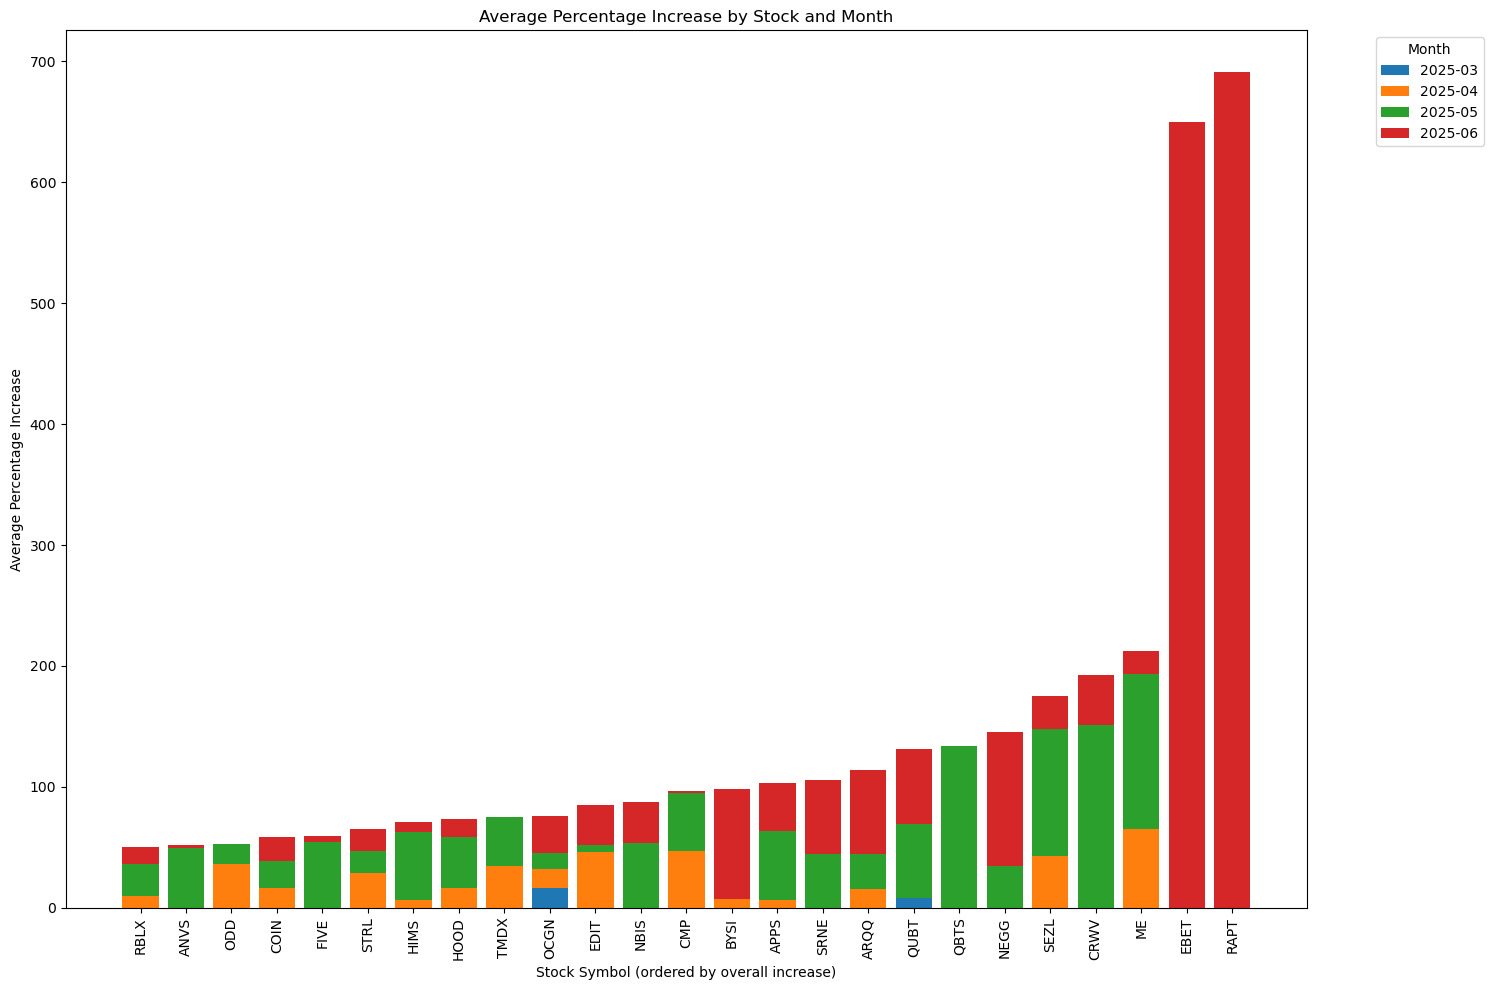

In [13]:
# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(15, 10))

bottom = np.zeros(len(sorted_df))

for month in sorted_df.columns:
    ax.bar(sorted_df.index, sorted_df[month], bottom=bottom, label=month)
    bottom += sorted_df[month]

# Customize the chart
ax.set_title('Average Percentage Increase by Stock and Month')
ax.set_xlabel('Stock Symbol (ordered by overall increase)')
ax.set_ylabel('Average Percentage Increase')
ax.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Adjust layout to prevent cutting off labels
plt.tight_layout()

# Show the plot
plt.show()